In [1]:
import itertools as it
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import torch.fft
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from toolbox import (
    make_loss,
    StatLoss,
    SINN,
    FPU
)

In [2]:
torch.cuda.is_available()

True

In [3]:
device = torch.device('cuda')

In [4]:
print(torch.__version__)
print(torch.version.cuda)

2.0.1+cu118
11.8


In [5]:
seed = 6666
torch.set_default_dtype(torch.float)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

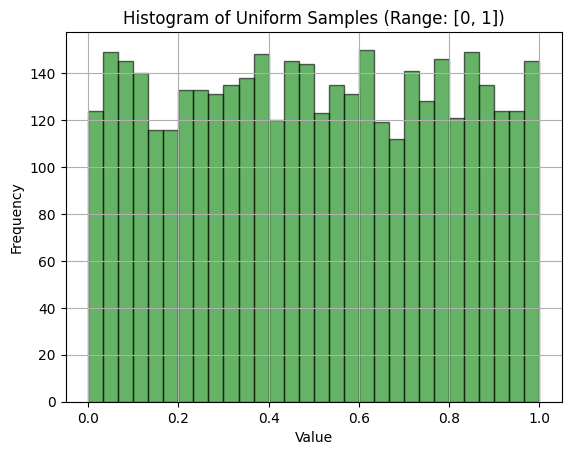

In [6]:
batch_size = 4000
# Generate sample points from a Uniform distribution (range: [low, high])
uniform_samples = np.random.uniform(low=0, high=1, size=batch_size).astype(np.float32)
uniform_samples = torch.tensor(uniform_samples).numpy()

# Plot Histogram
plt.hist(uniform_samples, bins=30, alpha=0.6, color='green', edgecolor='black')
plt.title('Histogram of Uniform Samples (Range: [0, 1])')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

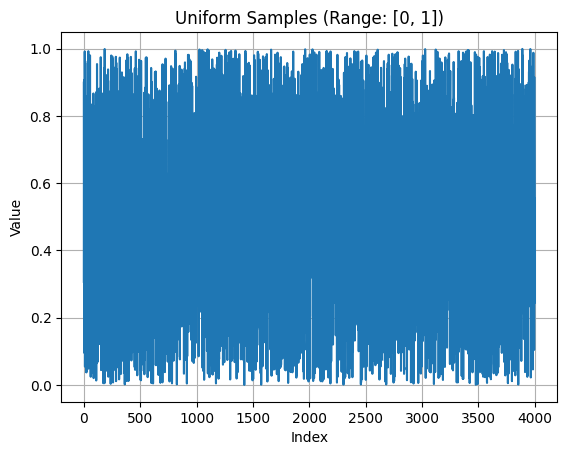

In [7]:
plt.plot(uniform_samples)
plt.title('Uniform Samples (Range: [0, 1])')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

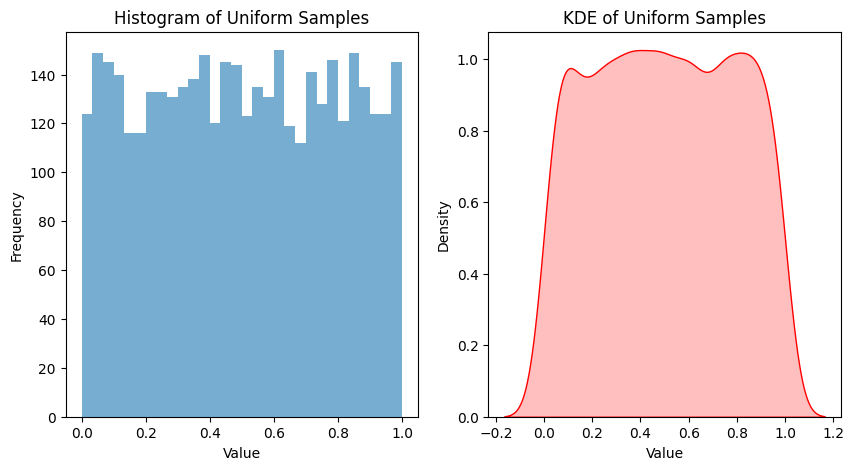

In [8]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(uniform_samples, bins=30, alpha=0.6)
plt.title('Histogram of Uniform Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(uniform_samples, color='red', fill=True)
plt.title('KDE of Uniform Samples')
plt.xlabel('Value')

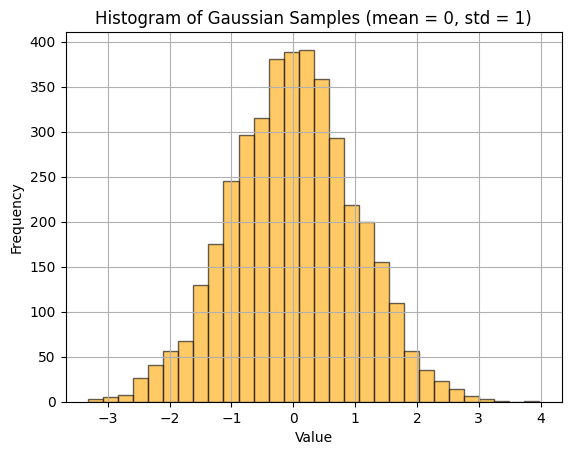

In [9]:
# Step 2: Generate 400 sample points from a Gaussian distribution (mean=0, std=1)
# gaussian_samples = np.random.normal(loc=0, scale=1, size=400).astype(np.float32)
gaussian_samples = norm.ppf(1-uniform_samples)
gaussian_samples = torch.tensor(gaussian_samples).numpy()

# Plot Histogram
plt.hist(gaussian_samples, bins=30, alpha=0.6, color='orange', edgecolor='black')
plt.title('Histogram of Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

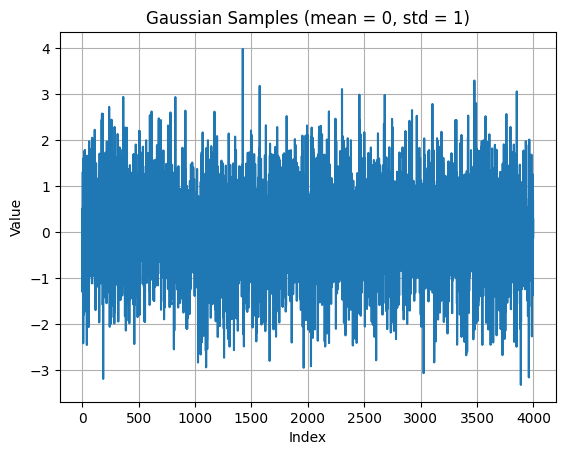

In [10]:
plt.plot(gaussian_samples)
plt.title('Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

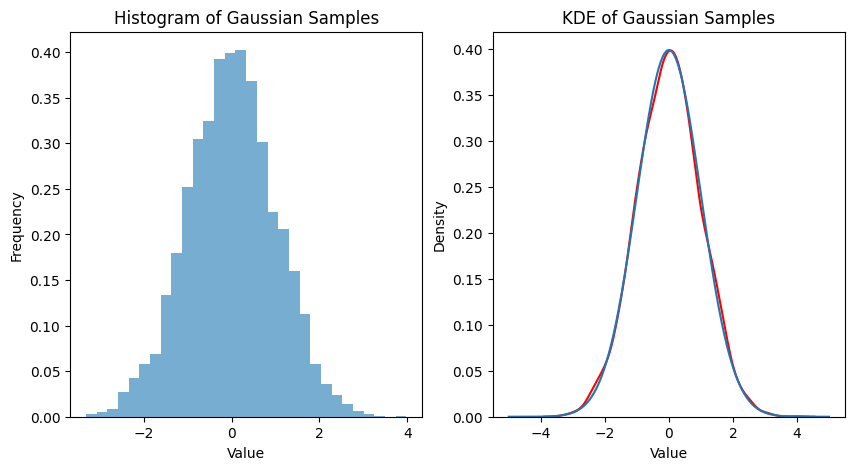

In [31]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples, bins=30, alpha=0.6, density=True)
plt.title('Histogram of Gaussian Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(gaussian_samples, color='red')
x_axis = np.arange(-5, 5, 0.0005)
# Mean = 0, SD = 1.
plt.plot(x_axis, norm.pdf(x_axis,0,1))
# plt.show()
plt.title('KDE of Gaussian Samples')
plt.xlabel('Value')

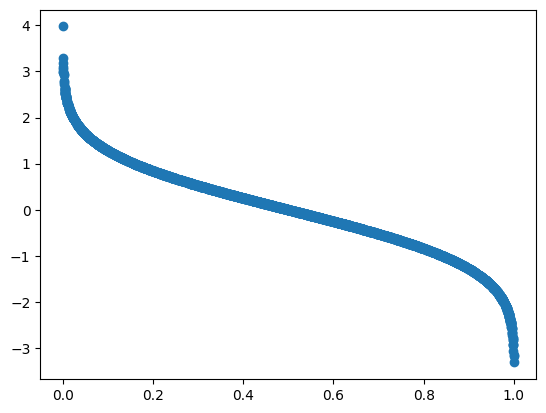

In [13]:
plt.scatter(uniform_samples, gaussian_samples)

In [14]:
uni_input = torch.from_numpy(uniform_samples.reshape(1, batch_size, 1)).to(device)
target = torch.from_numpy(gaussian_samples.reshape(1, batch_size, 1)).to(device)

In [15]:
loss_pdf_empirical = make_loss('pdf', target, lower=-5, upper=5, n=batch_size, bw=None, device=device)

Text(0.5, 0, 'Value')

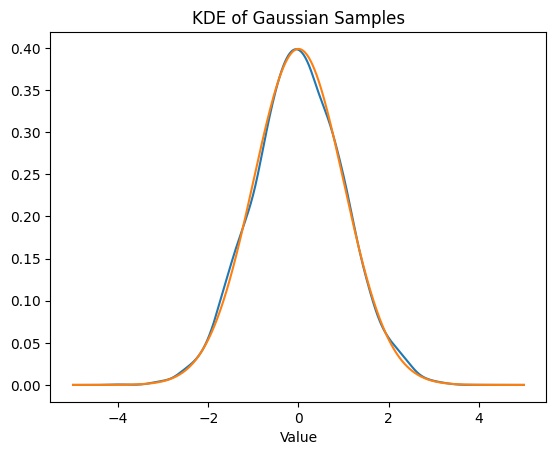

In [19]:
x_grid=-np.linspace(-5,5,num=batch_size)
plt.plot(x_grid, loss_pdf_empirical._target.cpu())
x_axis = np.arange(-5, 5, 0.0005)
# Mean = 0, SD = 1.
plt.plot(x_axis, norm.pdf(x_axis,0,1))
plt.title('KDE of Gaussian Samples')
plt.xlabel('Value')


In [21]:
class FNN(nn.Module):
    def __init__(self):
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(1, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 128)
        self.fc4 = nn.Linear(128, 1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.tanh(self.fc3(x))
        x = self.fc4(x)
        return x

In [22]:
# Initialize the neural network
model = FNN().to(device)

In [23]:
# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Initialize lists to store each moment loss over epochs
loss_list = []
epoch_list = []

# Training loop
num_epochs = 50000
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(uni_input)
    
    # Compute pdf loss
    loss = loss_pdf_empirical(outputs)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Store each moment loss and epoch number
    loss_list.append(loss.item())
    epoch_list.append(epoch + 1)
    
    # Logging every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.8f}')

        
    # Early stopping condition
    if (loss <= 0.000005):
        break


Epoch [100/50000], Loss: 0.00215609
Epoch [200/50000], Loss: 0.00162912
Epoch [300/50000], Loss: 0.00037370
Epoch [400/50000], Loss: 0.00022462
Epoch [500/50000], Loss: 0.00015710
Epoch [600/50000], Loss: 0.00010553
Epoch [700/50000], Loss: 0.00007461
Epoch [800/50000], Loss: 0.00005425
Epoch [900/50000], Loss: 0.00004062
Epoch [1000/50000], Loss: 0.00003187
Epoch [1100/50000], Loss: 0.00002622
Epoch [1200/50000], Loss: 0.00002243
Epoch [1300/50000], Loss: 0.00001975
Epoch [1400/50000], Loss: 0.00001775
Epoch [1500/50000], Loss: 0.00001617
Epoch [1600/50000], Loss: 0.00001488
Epoch [1700/50000], Loss: 0.00001377
Epoch [1800/50000], Loss: 0.00001280
Epoch [1900/50000], Loss: 0.00001192
Epoch [2000/50000], Loss: 0.00001112
Epoch [2100/50000], Loss: 0.00001037
Epoch [2200/50000], Loss: 0.00000969
Epoch [2300/50000], Loss: 0.00001484
Epoch [2400/50000], Loss: 0.00000850
Epoch [2500/50000], Loss: 0.00000799
Epoch [2600/50000], Loss: 0.00000754
Epoch [2700/50000], Loss: 0.00000714
Epoch [280

Text(0, 0.5, '$l_2$')

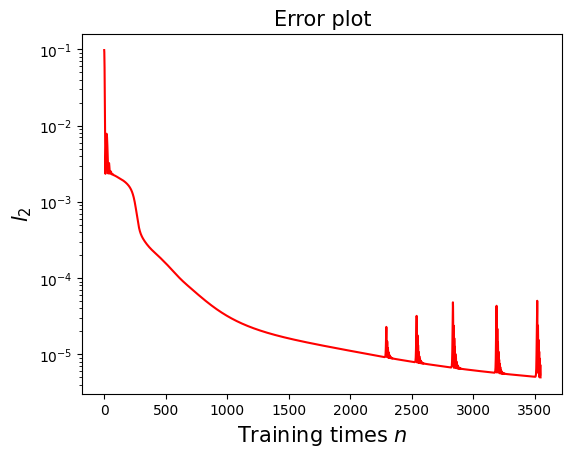

In [24]:
fig = plt.figure(1)
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
plt.title("Error plot",fontsize=15) 
plt.yscale('log')
plt.plot(epoch_list, loss_list,'r',label='Training error')
plt.xlabel(r'Training times $n$',fontsize=15)
plt.ylabel(r'$l_2$',fontsize=15)

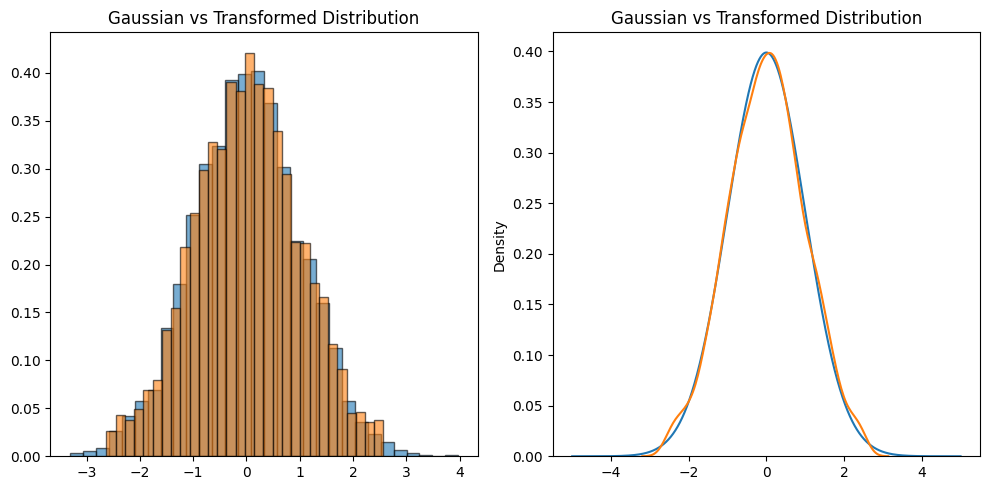

In [30]:
input = np.linspace(0,1,batch_size).astype(np.float32)
input_test = torch.from_numpy(input.reshape(1, batch_size, 1)).to(device)

# Test the transformation
with torch.no_grad():
    transformed_samples = model(uni_input)


# Step 7: Plot the original and transformed distributions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples, bins=30, alpha=0.6, density=True, edgecolor='black')
plt.hist(transformed_samples.cpu().reshape(batch_size), bins=30, alpha=0.6, density=True, edgecolor='black')
plt.title('Gaussian vs Transformed Distribution')


plt.subplot(1, 2, 2)
x_axis = np.arange(-5, 5, 0.0005)
# Mean = 0, SD = 1.
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
plt.title('Gaussian vs Transformed Distribution')


plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frequency')

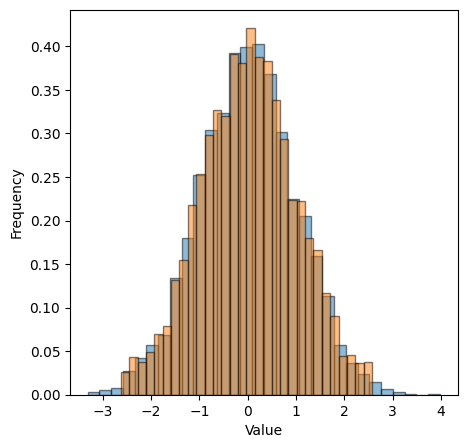

In [38]:
plt.figure(figsize=(5, 5))
plt.hist(gaussian_samples, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples.cpu().reshape(batch_size), bins=30, alpha=0.5, density=True, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')

Text(0.5, 0, 'Value')

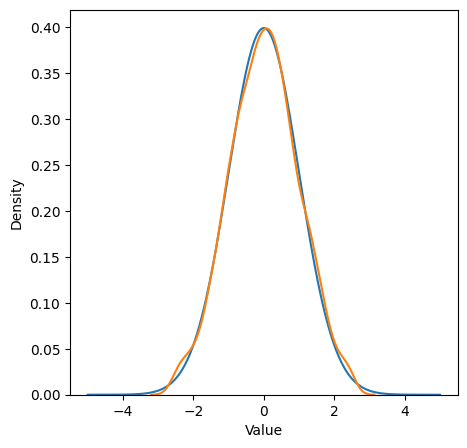

In [40]:
plt.figure(figsize=(5, 5))
# Normal distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')
plt.xlabel('Value')

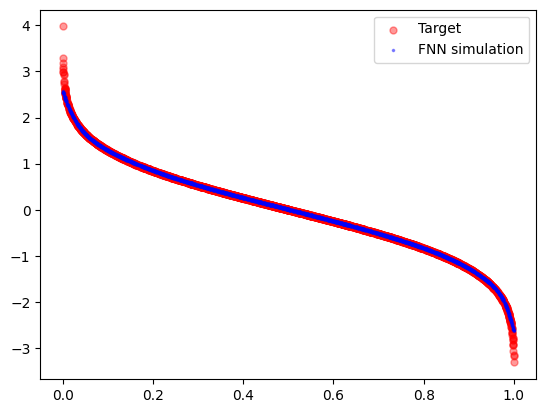

In [29]:
plt.scatter(uniform_samples, gaussian_samples, c='r', s=25, alpha=0.4, marker='o', label='Target')
plt.scatter(uni_input.cpu().reshape(batch_size), transformed_samples.cpu().reshape(batch_size), c='b', s=10, alpha=0.4,marker='.',label='FNN simulation')
plt.legend()